# Llama 3.1 8B Experiments - Simplified Labels (No BIO Tags)

This notebook runs NER experiments with `llama3.1:8b` model on the simplified dataset (140 samples).

**Key Changes**: 
- Labels use simple entity types (PERSON, LOCATION, etc.) without BIO tags (B-/I- prefixes)
- MISC labels have been converted to O - focusing on 5 main entity types: PERSON, ORGANIZATION, LOCATION, TIME, CURRENCY

Tests: zero-shot, few-shot, and chain-of-thought prompting.

## Approach
- Each token is classified into an entity type (or O)
- No BIO structure - simpler token classification
- Entity spans extracted by grouping consecutive same-type tokens


In [2]:
# Cell 1: Setup and Imports
import json
import os
import re
import time
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Configuration
MODEL_NAME = "llama3.1:8b"
OLLAMA_BASE_URL = "http://localhost:11434"
DATA_PATH = "../data/selected_140_ontonotes5_samples_no_misc.json"  # MISC converted to O
PROMPT_TYPES = ['zero_shot', 'few_shot', 'chain_of_thought']

print("✅ Imports and configuration complete")


✅ Imports and configuration complete


In [3]:
# Cell 2: Load Simplified Dataset
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

data = dataset['samples']

print(f"✅ Loaded {len(data)} samples from the dataset")
print(f"Metadata: {dataset.get('metadata', {})}")

# Show example
if len(data) > 0:
    example = data[0]
    print(f"\nExample sample:")
    print(f"  Text: {example['text']}")
    print(f"  Tokens: {example['tokens'][:5]}...")
    print(f"  Labels: {example['labels'][:5]}...")


✅ Loaded 140 samples from the dataset
Metadata: {'total_samples': 140, 'conversion_date': '2025-12-21T01:25:02.354563', 'conversion_note': 'MISC labels converted to O - focus on 5 main entity types (PERSON, ORGANIZATION, LOCATION, TIME, CURRENCY)', 'original_file': 'selected_140_ontonotes5_samples_simplified.json', 'misc_labels_converted': 103, 'total_labels': 3556}

Example sample:
  Text: Hearings have n't yet been set in Texas , Ohio and Kansas .
  Tokens: ['Hearings', 'have', "n't", 'yet', 'been']...
  Labels: ['O', 'O', 'O', 'O', 'O']...


Label Distribution:
O              :  2801 (78.77%)
TIME           :   220 ( 6.19%)
ORGANIZATION   :   190 ( 5.34%)
CURRENCY       :   129 ( 3.63%)
PERSON         :   124 ( 3.49%)
LOCATION       :    92 ( 2.59%)

Entity types in dataset: ['CURRENCY', 'LOCATION', 'ORGANIZATION', 'PERSON', 'TIME']


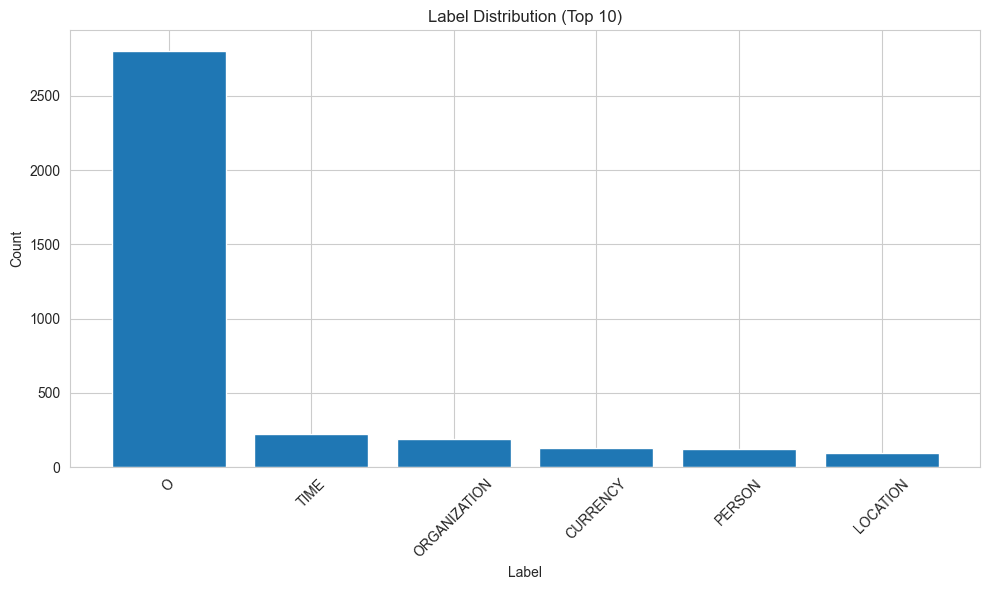

In [4]:
# Cell 3: Data Exploration
# Label distribution
all_labels = []
for sample in data:
    all_labels.extend(sample['labels'])

label_counts = Counter(all_labels)
print("Label Distribution:")
print("=" * 60)
for label, count in label_counts.most_common():
    pct = count / len(all_labels) * 100
    print(f"{label:15s}: {count:5d} ({pct:5.2f}%)")

# Entity types present
entity_types = [label for label in label_counts.keys() if label != 'O']
print(f"\nEntity types in dataset: {sorted(entity_types)}")

# Visualize label distribution
plt.figure(figsize=(10, 6))
labels_list = [label for label, _ in label_counts.most_common(10)]
counts_list = [count for _, count in label_counts.most_common(10)]
plt.bar(labels_list, counts_list)
plt.title('Label Distribution (Top 10)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
# Cell 4: Define Prompt Functions

def create_zero_shot_prompt(sentence: str) -> str:
    """Create zero-shot prompt with entity-level JSON output"""
    prompt = f"""You are an expert Named Entity Recognition system.
Extract ALL entities from the sentence below using these types only:
- PERSON: People names (e.g., "John Smith", "Barack Obama")
- LOCATION: Places - cities, countries, regions (e.g., "Paris", "France", "New York")
- ORGANIZATION: Companies, agencies, institutions, teams (e.g., "Microsoft", "United Nations")
- TIME: Dates, years, durations, temporal expressions:
  * Full dates: "January 1, 2025", "1996-08-30"
  * Years: "2023", "in 1996"
  * Relative: "last week", "Monday morning", "past four years"
  * Durations: "two days", "four years"
- CURRENCY: Monetary amounts, including:
  * With symbol: "$100", "€50 million", "£25 billion", "¥1.5bn"
  * With name: "100 dollars", "50 million euros", "1.5 billion yen", "10m pounds"
  * Abbreviations: "100m", "1.5bn" when clearly monetary
  * Always include the unit (e.g., "100 dollars", not just "100")

Output ONLY a valid JSON array. No extra text, explanations, or reasoning outside the JSON.
Format: [{{"entity": "exact text span", "type": "PERSON|LOCATION|ORGANIZATION|TIME|CURRENCY"}}, ...]
If no entities found, output [].

Example:
Sentence: John Smith visited Paris in 2023 for $100.
Output: [{{"entity": "John Smith", "type": "PERSON"}}, {{"entity": "Paris", "type": "LOCATION"}}, {{"entity": "2023", "type": "TIME"}}, {{"entity": "$100", "type": "CURRENCY"}}]

Sentence: {sentence}
Output:"""
    return prompt


def create_few_shot_prompt(sentence: str, examples: List[Dict]) -> str:
    """Create few-shot prompt with entity-level JSON output"""
    prompt = """You are an expert Named Entity Recognition system.
Extract ALL entities from sentences using these types only:
- PERSON: People names
- LOCATION: Places (cities, countries, regions)
- ORGANIZATION: Companies, agencies, institutions
- TIME: Dates, years, durations ("2023", "last week", "four years")
- CURRENCY: Money with symbol or name ("$100", "50 million euros", "1.5 billion yen")

Output ONLY a valid JSON array. Format: [{"entity": "exact text span", "type": "TYPE"}, ...]

Here are examples:

"""
    
    for i, example in enumerate(examples, 1):
        text = example.get('text', '')
        tokens = example.get('tokens', [])
        labels = example.get('labels', [])
        
        # Convert token-level labels to entity spans for the example
        entities = extract_entities_from_labels(tokens, labels)
        entity_list = [{"entity": entity[3], "type": entity[0]} for entity in entities]
        
        prompt += f"Example {i}:\n"
        prompt += f"Sentence: {text}\n"
        prompt += f"Output: {json.dumps(entity_list)}\n\n"
    
    prompt += f"Now extract entities from this sentence:\n"
    prompt += f"Sentence: {sentence}\n"
    prompt += f"Output:"
    return prompt


def create_chain_of_thought_prompt(sentence: str) -> str:
    """Create chain-of-thought prompt with entity-level JSON output"""
    prompt = f"""You are an expert Named Entity Recognition system.
Extract ALL entities from the sentence below using these types:
- PERSON: People names
- LOCATION: Places (cities, countries, regions)
- ORGANIZATION: Companies, agencies, institutions
- TIME: Dates, years, durations ("2023", "last week", "four years")
- CURRENCY: Money with symbol or name ("$100", "50 million euros", "1.5 billion yen")

Sentence: {sentence}

Think step-by-step:
1. List all PERSON names you find
2. List all ORGANIZATION names you find
3. List all LOCATION names you find
4. List all TIME expressions you find
5. List all CURRENCY expressions you find

After reasoning, output ONLY a valid JSON array. No extra text.
Format: [{{"entity": "exact text span", "type": "TYPE"}}, ...]

Reasoning:"""
    return prompt


def select_diverse_few_shot_examples(data: List[Dict], num_examples: int = 5) -> List[Dict]:
    """Select diverse few-shot examples that cover different entity types and patterns"""
    # Count entities per sample
    samples_with_entities = []
    for sample in data:
        labels = sample['labels']
        entity_counts = {}
        for label in labels:
            if label != 'O':
                entity_counts[label] = entity_counts.get(label, 0) + 1
        samples_with_entities.append({
            'sample': sample,
            'entities': entity_counts,
            'entity_types': set([l for l in labels if l != 'O'])
        })
    
    # Select examples to maximize coverage
    selected = []
    covered_entity_types = set()
    
    # Prioritize samples with CURRENCY (often harder to detect)
    currency_samples = [s for s in samples_with_entities if 'CURRENCY' in s['entity_types']]
    if currency_samples:
        selected.append(currency_samples[0]['sample'])
        covered_entity_types.update(currency_samples[0]['entity_types'])
        samples_with_entities.remove(currency_samples[0])
    
    # Prioritize samples with TIME (often has low recall)
    time_samples = [s for s in samples_with_entities if 'TIME' in s['entity_types']]
    if time_samples:
        selected.append(time_samples[0]['sample'])
        covered_entity_types.update(time_samples[0]['entity_types'])
        samples_with_entities.remove(time_samples[0])
    
    # Select samples with multi-word entities (ORGANIZATION often multi-word)
    org_samples = [s for s in samples_with_entities if 'ORGANIZATION' in s['entity_types']]
    if org_samples:
        # Find one with multi-word organization
        for org_sample in org_samples:
            labels = org_sample['sample']['labels']
            tokens = org_sample['sample']['tokens']
            # Check if there's a multi-word organization
            has_multi_word = False
            for i, label in enumerate(labels):
                if label == 'ORGANIZATION' and i > 0 and labels[i-1] == 'ORGANIZATION':
                    has_multi_word = True
                    break
            if has_multi_word:
                selected.append(org_sample['sample'])
                covered_entity_types.update(org_sample['entity_types'])
                samples_with_entities.remove(org_sample)
                break
        else:
            # Fallback: just take first org sample
            selected.append(org_samples[0]['sample'])
            covered_entity_types.update(org_samples[0]['entity_types'])
            samples_with_entities.remove(org_samples[0])
    
    # Fill remaining slots with diverse examples
    remaining_needed = num_examples - len(selected)
    for _ in range(min(remaining_needed, len(samples_with_entities))):
        if not samples_with_entities:
            break
        
        # Prefer samples with entity types not yet covered
        best_sample = None
        best_score = -1
        
        for s in samples_with_entities[:20]:  # Check first 20 to avoid too much computation
            # Score based on new entity types and entity count
            new_types = s['entity_types'] - covered_entity_types
            score = len(new_types) * 10 + len(s['entity_types'])
            
            if score > best_score:
                best_score = score
                best_sample = s
        
        if best_sample:
            selected.append(best_sample['sample'])
            covered_entity_types.update(best_sample['entity_types'])
            samples_with_entities.remove(best_sample)
        else:
            # Fallback: just take next sample
            selected.append(samples_with_entities[0]['sample'])
            samples_with_entities.pop(0)
    
    return selected[:num_examples]


print("✅ Prompt functions defined")


✅ Prompt functions defined


In [ ]:
# Cell 5: Prediction Function

def generate_with_ollama(prompt: str, model_name: str = MODEL_NAME, max_retries: int = 3) -> str:
    """Call Ollama API to generate response"""
    url = f"{OLLAMA_BASE_URL}/api/generate"
    
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {
            "num_predict": 1000,
            "temperature": 0.0
        }
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.post(url, json=payload, timeout=60)
            response.raise_for_status()
            result = response.json()
            return result.get('response', '').strip()
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2)
            else:
                raise
    
    return ""


def parse_entities_from_json_response(response: str) -> List[Dict[str, str]]:
    """Parse entities from JSON response"""
    import json
    import re
    
    # Try to extract JSON from response (handle cases where model adds extra text)
    response = response.strip()
    
    # Find JSON array in response
    json_match = re.search(r'\[.*\]', response, re.DOTALL)
    if json_match:
        json_str = json_match.group(0)
        try:
            entities = json.loads(json_str)
            if isinstance(entities, list):
                # Validate and normalize entities
                valid_entities = []
                for entity in entities:
                    if isinstance(entity, dict) and 'entity' in entity and 'type' in entity:
                        valid_entities.append({
                            'entity': str(entity['entity']).strip(),
                            'type': str(entity['type']).strip().upper()
                        })
                return valid_entities
        except json.JSONDecodeError:
            pass
    
    # Fallback: try parsing the whole response as JSON
    try:
        entities = json.loads(response)
        if isinstance(entities, list):
            valid_entities = []
            for entity in entities:
                if isinstance(entity, dict) and 'entity' in entity and 'type' in entity:
                    valid_entities.append({
                        'entity': str(entity['entity']).strip(),
                        'type': str(entity['type']).strip().upper()
                    })
            return valid_entities
    except json.JSONDecodeError:
        pass
    
    return []


def entities_to_token_labels(entities: List[Dict[str, str]], text: str, tokens: List[str]) -> List[str]:
    """Convert entity spans to token-level labels"""
    # Initialize all tokens as 'O'
    labels = ['O'] * len(tokens)
    
    # Create token positions in text
    token_positions = []
    text_lower = text.lower()
    token_lower = [t.lower() for t in tokens]
    
    start_idx = 0
    for token in tokens:
        # Find token in text (case-insensitive)
        pos = text_lower.find(token.lower(), start_idx)
        if pos != -1:
            token_positions.append((pos, pos + len(token)))
            start_idx = pos + len(token)
        else:
            # Fallback: approximate position
            token_positions.append((start_idx, start_idx + len(token)))
            start_idx += len(token) + 1
    
    # Mark entities
    for entity_dict in entities:
        entity_text = entity_dict['entity']
        entity_type = entity_dict['type']
        
        # Find entity in text (case-insensitive, fuzzy match)
        entity_lower = entity_text.lower()
        entity_start = text_lower.find(entity_lower)
        
        if entity_start != -1:
            entity_end = entity_start + len(entity_text)
            
            # Find tokens that overlap with this entity
            for i, (tok_start, tok_end) in enumerate(token_positions):
                # Check if token overlaps with entity span
                if (tok_start < entity_end and tok_end > entity_start):
                    labels[i] = entity_type
    
    return labels


def parse_labels_from_response(response: str, tokens: List[str], text: str = "") -> List[str]:
    """Robust parser: extract JSON entities first, fallback to regex for space-separated labels"""
    # Try JSON parsing first (preferred method)
    entities = parse_entities_from_json_response(response)
    
    if entities and text:
        # Convert entities to token-level labels
        labels = entities_to_token_labels(entities, text, tokens)
        if labels and any(l != 'O' for l in labels):  # Check if we got valid labels
            return labels
    
    # Fallback: Try regex for space-separated labels
    import re
    valid_types = ['PERSON', 'ORGANIZATION', 'LOCATION', 'TIME', 'CURRENCY', 'O']
    labels_pattern = r'\b(?:' + '|'.join(valid_types) + r')\b'
    matches = re.findall(labels_pattern, response.upper())
    
    if matches and len(matches) >= len(tokens) * 0.5:  # At least 50% coverage
        if len(matches) == len(tokens):
            return matches
        elif len(matches) > len(tokens):
            return matches[:len(tokens)]
        else:
            # Pad with O
            return matches + ['O'] * (len(tokens) - len(matches))
    
    # Final fallback: all O
    if not text or not tokens:
        print(f"⚠️ Parse fail (no text/tokens), using O: {response[:100]}...")
    return ['O'] * len(tokens)


def predict(sentence: str, prompt_type: str, examples: Optional[List[Dict]] = None, 
            tokens: Optional[List[str]] = None, max_retries: int = 3) -> List[str]:
    """Predict labels for a sentence with retry logic"""
    if tokens is None:
        tokens = sentence.split()
    
    # Get prompt
    if prompt_type == 'zero_shot':
        prompt = create_zero_shot_prompt(sentence)
    elif prompt_type == 'few_shot':
        if examples is None:
            raise ValueError("Examples required for few-shot prompting")
        prompt = create_few_shot_prompt(sentence, examples)
    elif prompt_type == 'chain_of_thought':
        prompt = create_chain_of_thought_prompt(sentence)
    else:
        raise ValueError(f"Unknown prompt type: {prompt_type}")
    
    # Retry logic with exponential backoff
    for retry in range(max_retries):
        try:
            # Get model response with timeout
            response = generate_with_ollama(prompt)
            
            # Parse labels (need original sentence text for span matching)
            labels = parse_labels_from_response(response, tokens, sentence)
            
            # Validate we got reasonable output (not all O unless sentence is very short)
            if len(tokens) > 3 and all(l == 'O' for l in labels):
                # Might be parsing failure, retry with different temperature
                if retry < max_retries - 1:
                    time.sleep(2 ** retry)  # Exponential backoff
                    continue
            
            return labels
            
        except Exception as e:
            if retry < max_retries - 1:
                print(f"⚠️ Prediction error (retry {retry + 1}/{max_retries}): {str(e)[:50]}...")
                time.sleep(2 ** retry)  # Exponential backoff
            else:
                print(f"❌ Prediction failed after {max_retries} retries: {str(e)[:50]}...")
                return ['O'] * len(tokens)
    
    return ['O'] * len(tokens)


print("✅ Prediction functions defined")


✅ Prediction functions defined


In [7]:
# Cell 6: Evaluation Functions

def calculate_token_level_metrics(true_labels: List[List[str]], pred_labels: List[List[str]]) -> Dict:
    """Calculate token-level classification metrics"""
    # Flatten all labels
    all_true = [label for labels in true_labels for label in labels]
    all_pred = [label for labels in pred_labels for label in labels]
    
    # Get all unique labels
    all_labels_set = set(all_true + all_pred)
    entity_types = [l for l in sorted(all_labels_set) if l != 'O']
    
    metrics = {}
    
    # Per-entity-type metrics
    for entity_type in entity_types:
        # True positives: predicted as entity_type and actually entity_type
        tp = sum(1 for t, p in zip(all_true, all_pred) if t == entity_type and p == entity_type)
        # False positives: predicted as entity_type but actually not
        fp = sum(1 for t, p in zip(all_true, all_pred) if t != entity_type and p == entity_type)
        # False negatives: actually entity_type but predicted as something else
        fn = sum(1 for t, p in zip(all_true, all_pred) if t == entity_type and p != entity_type)
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        
        metrics[f'Precision_{entity_type}'] = precision
        metrics[f'Recall_{entity_type}'] = recall
        metrics[f'F1_{entity_type}'] = f1
        metrics[f'TP_{entity_type}'] = tp
        metrics[f'FP_{entity_type}'] = fp
        metrics[f'FN_{entity_type}'] = fn
    
    # Overall metrics (micro-averaged)
    tp_all = sum(1 for t, p in zip(all_true, all_pred) if t == p and t != 'O')
    fp_all = sum(1 for t, p in zip(all_true, all_pred) if t != p and p != 'O')
    fn_all = sum(1 for t, p in zip(all_true, all_pred) if t != p and t != 'O')
    
    precision_overall = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
    recall_overall = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
    f1_overall = 2 * precision_overall * recall_overall / (precision_overall + recall_overall) if (precision_overall + recall_overall) > 0 else 0.0
    
    # Token-level accuracy
    accuracy = sum(1 for t, p in zip(all_true, all_pred) if t == p) / len(all_true) if all_true else 0.0
    
    metrics['Precision_Overall'] = precision_overall
    metrics['Recall_Overall'] = recall_overall
    metrics['F1_Overall'] = f1_overall
    metrics['Accuracy'] = accuracy
    metrics['TP_Overall'] = tp_all
    metrics['FP_Overall'] = fp_all
    metrics['FN_Overall'] = fn_all
    
    return metrics


def extract_entities_from_labels(tokens: List[str], labels: List[str]) -> List[Tuple[str, int, int, str]]:
    """Extract entity spans by grouping consecutive tokens with same entity type"""
    entities = []
    current_entity = None
    
    for i, (token, label) in enumerate(zip(tokens, labels)):
        if label != 'O':
            if current_entity is None:
                # Start new entity
                current_entity = (label, i, i, token)
            elif current_entity[0] == label:
                # Continue entity
                entity_type, start, _, text = current_entity
                current_entity = (entity_type, start, i, text + ' ' + token)
            else:
                # Different entity type - save previous and start new
                entities.append(current_entity)
                current_entity = (label, i, i, token)
        else:
            # O label - end current entity if any
            if current_entity is not None:
                entities.append(current_entity)
                current_entity = None
    
    # Add last entity if exists
    if current_entity is not None:
        entities.append(current_entity)
    
    return entities


print("✅ Evaluation functions defined")


✅ Evaluation functions defined


In [8]:
# Cell 7: Run Zero-Shot Experiment

print("=" * 70)
print("Running Zero-Shot Experiment")
print("=" * 70)

zero_shot_predictions = []
zero_shot_true_labels = []
zero_shot_tokens_list = []

for idx, sample in enumerate(tqdm(data, desc="Zero-shot")):
    sentence = sample['text']
    tokens = sample['tokens']
    true_labels = sample['labels']
    
    try:
        if idx > 0:
            time.sleep(1.0)  # Delay to prevent overwhelming the model
        
        pred_labels = predict(sentence, 'zero_shot')
        zero_shot_predictions.append(pred_labels)
        zero_shot_true_labels.append(true_labels)
        zero_shot_tokens_list.append(tokens)
    except Exception as e:
        print(f"\nError at sample {idx + 1}: {e}")
        # Fallback: use all 'O' labels
        zero_shot_predictions.append(['O'] * len(tokens))
        zero_shot_true_labels.append(true_labels)
        zero_shot_tokens_list.append(tokens)

# Calculate metrics
zero_shot_metrics = calculate_token_level_metrics(zero_shot_true_labels, zero_shot_predictions)

print("\nZero-Shot Results:")
print(f"  Accuracy: {zero_shot_metrics['Accuracy']:.4f}")
print(f"  F1 Overall: {zero_shot_metrics['F1_Overall']:.4f}")
print(f"  Precision Overall: {zero_shot_metrics['Precision_Overall']:.4f}")
print(f"  Recall Overall: {zero_shot_metrics['Recall_Overall']:.4f}")
print()

# Per-entity-type metrics
entity_types = ['PERSON', 'ORGANIZATION', 'LOCATION', 'TIME', 'CURRENCY']
print("Per-Entity-Type Metrics:")
print("=" * 70)
print(f"{'Entity Type':<15s} {'F1':<8s} {'Precision':<10s} {'Recall':<10s} {'TP':<6s} {'FP':<6s} {'FN':<6s}")
print("-" * 70)
for entity_type in entity_types:
    f1_key = f'F1_{entity_type}'
    precision_key = f'Precision_{entity_type}'
    recall_key = f'Recall_{entity_type}'
    tp_key = f'TP_{entity_type}'
    fp_key = f'FP_{entity_type}'
    fn_key = f'FN_{entity_type}'
    
    if f1_key in zero_shot_metrics:
        f1 = zero_shot_metrics.get(f1_key, 0.0)
        precision = zero_shot_metrics.get(precision_key, 0.0)
        recall = zero_shot_metrics.get(recall_key, 0.0)
        tp = zero_shot_metrics.get(tp_key, 0)
        fp = zero_shot_metrics.get(fp_key, 0)
        fn = zero_shot_metrics.get(fn_key, 0)
        
        print(f"{entity_type:<15s} {f1:<8.4f} {precision:<10.4f} {recall:<10.4f} {tp:<6d} {fp:<6d} {fn:<6d}")
    else:
        print(f"{entity_type:<15s} {'0.0000':<8s} {'0.0000':<10s} {'0.0000':<10s} {'0':<6s} {'0':<6s} {'0':<6s}")
print("=" * 70)


Running Zero-Shot Experiment


Zero-shot: 100%|██████████| 140/140 [10:08<00:00,  4.35s/it]


Zero-Shot Results:
  Accuracy: 0.8777
  F1 Overall: 0.6781
  Precision Overall: 0.7353
  Recall Overall: 0.6291

Per-Entity-Type Metrics:
Entity Type     F1       Precision  Recall     TP     FP     FN    
----------------------------------------------------------------------
PERSON          0.7987   0.6839     0.9597     119    55     5     
ORGANIZATION    0.7638   0.7308     0.8000     152    56     38    
LOCATION        0.8280   0.8191     0.8370     77     17     15    
TIME            0.5556   0.8654     0.4091     90     14     130   
CURRENCY        0.3915   0.6167     0.2868     37     23     92    


In [9]:
# Cell 8: Run Few-Shot Experiment

print("=" * 70)
print("Running Few-Shot Experiment")
print("=" * 70)

# Prepare few-shot examples (select diverse examples covering different entity types)
few_shot_examples = select_diverse_few_shot_examples(data, num_examples=5)
print(f"Using {len(few_shot_examples)} diverse examples for few-shot prompting")
print("Few-shot example entity types:")
for i, ex in enumerate(few_shot_examples, 1):
    entity_types = set([l for l in ex['labels'] if l != 'O'])
    print(f"  Example {i}: {sorted(entity_types) if entity_types else 'No entities'}")

few_shot_predictions = []
few_shot_true_labels = []
few_shot_tokens_list = []

for idx, sample in enumerate(tqdm(data, desc="Few-shot")):
    sentence = sample['text']
    tokens = sample['tokens']
    true_labels = sample['labels']
    
    try:
        if idx > 0:
            time.sleep(1.0)  # Delay to prevent overwhelming the model
        
        pred_labels = predict(sentence, 'few_shot', few_shot_examples)
        few_shot_predictions.append(pred_labels)
        few_shot_true_labels.append(true_labels)
        few_shot_tokens_list.append(tokens)
    except Exception as e:
        print(f"\nError at sample {idx + 1}: {e}")
        # Fallback: use all 'O' labels
        few_shot_predictions.append(['O'] * len(tokens))
        few_shot_true_labels.append(true_labels)
        few_shot_tokens_list.append(tokens)

# Calculate metrics
few_shot_metrics = calculate_token_level_metrics(few_shot_true_labels, few_shot_predictions)

print("\nFew-Shot Results:")
print(f"  Accuracy: {few_shot_metrics['Accuracy']:.4f}")
print(f"  F1 Overall: {few_shot_metrics['F1_Overall']:.4f}")
print(f"  Precision Overall: {few_shot_metrics['Precision_Overall']:.4f}")
print(f"  Recall Overall: {few_shot_metrics['Recall_Overall']:.4f}")
print()

# Per-entity-type metrics
entity_types = ['PERSON', 'ORGANIZATION', 'LOCATION', 'TIME', 'CURRENCY']
print("Per-Entity-Type Metrics:")
print("-" * 70)
print(f"{'Entity Type':<15s} {'F1':<8s} {'Precision':<10s} {'Recall':<10s} {'TP':<6s} {'FP':<6s} {'FN':<6s}")
print("-" * 70)
for entity_type in entity_types:
    f1_key = f'F1_{entity_type}'
    precision_key = f'Precision_{entity_type}'
    recall_key = f'Recall_{entity_type}'
    tp_key = f'TP_{entity_type}'
    fp_key = f'FP_{entity_type}'
    fn_key = f'FN_{entity_type}'
    
    if f1_key in few_shot_metrics:
        f1 = few_shot_metrics.get(f1_key, 0.0)
        precision = few_shot_metrics.get(precision_key, 0.0)
        recall = few_shot_metrics.get(recall_key, 0.0)
        tp = few_shot_metrics.get(tp_key, 0)
        fp = few_shot_metrics.get(fp_key, 0)
        fn = few_shot_metrics.get(fn_key, 0)
        
        print(f"{entity_type:<15s} {f1:<8.4f} {precision:<10.4f} {recall:<10.4f} {tp:<6d} {fp:<6d} {fn:<6d}")
    else:
        print(f"{entity_type:<15s} {'0.0000':<8s} {'0.0000':<10s} {'0.0000':<10s} {'0':<6s} {'0':<6s} {'0':<6s}")


Running Few-Shot Experiment
Using 5 diverse examples for few-shot prompting
Few-shot example entity types:
  Example 1: ['CURRENCY', 'ORGANIZATION', 'TIME']
  Example 2: ['ORGANIZATION', 'TIME']
  Example 3: ['ORGANIZATION']
  Example 4: ['LOCATION']
  Example 5: ['PERSON']


Few-shot: 100%|██████████| 140/140 [12:02<00:00,  5.16s/it]


Few-Shot Results:
  Accuracy: 0.8898
  F1 Overall: 0.7398
  Precision Overall: 0.7252
  Recall Overall: 0.7550

Per-Entity-Type Metrics:
----------------------------------------------------------------------
Entity Type     F1       Precision  Recall     TP     FP     FN    
----------------------------------------------------------------------
PERSON          0.8203   0.7076     0.9758     121    50     3     
ORGANIZATION    0.7991   0.7253     0.8895     169    64     21    
LOCATION        0.7404   0.6638     0.8370     77     39     15    
TIME            0.6611   0.8613     0.5364     118    19     102   
CURRENCY        0.6589   0.6589     0.6589     85     44     44    


In [10]:
# Cell 9: Run Chain-of-Thought Experiment

print("=" * 70)
print("Running Chain-of-Thought Experiment")
print("=" * 70)

cot_predictions = []
cot_true_labels = []
cot_tokens_list = []

for idx, sample in enumerate(tqdm(data, desc="Chain-of-Thought")):
    sentence = sample['text']
    tokens = sample['tokens']
    true_labels = sample['labels']
    
    try:
        if idx > 0:
            time.sleep(1.5)  # Delay to prevent overwhelming the model
        
        pred_labels = predict(sentence, 'chain_of_thought', tokens=tokens)
        cot_predictions.append(pred_labels)
        cot_true_labels.append(true_labels)
        cot_tokens_list.append(tokens)
    except Exception as e:
        print(f"\n❌ Error at sample {idx + 1}: {e}")
        # Fallback: use all 'O' labels
        cot_predictions.append(['O'] * len(tokens))
        cot_true_labels.append(true_labels)
        cot_tokens_list.append(tokens)

# Calculate metrics
cot_metrics = calculate_token_level_metrics(cot_true_labels, cot_predictions)

print("\nChain-of-Thought Results:")
print(f"  Accuracy: {cot_metrics['Accuracy']:.4f}")
print(f"  F1 Overall: {cot_metrics['F1_Overall']:.4f}")
print(f"  Precision Overall: {cot_metrics['Precision_Overall']:.4f}")
print(f"  Recall Overall: {cot_metrics['Recall_Overall']:.4f}")
print()

# Per-entity-type metrics
entity_types = ['PERSON', 'ORGANIZATION', 'LOCATION', 'TIME', 'CURRENCY']
print("Per-Entity-Type Metrics:")
print("=" * 70)
print(f"{'Entity Type':<15s} {'F1':<8s} {'Precision':<10s} {'Recall':<10s} {'TP':<6s} {'FP':<6s} {'FN':<6s}")
print("-" * 70)
for entity_type in entity_types:
    f1_key = f'F1_{entity_type}'
    precision_key = f'Precision_{entity_type}'
    recall_key = f'Recall_{entity_type}'
    tp_key = f'TP_{entity_type}'
    fp_key = f'FP_{entity_type}'
    fn_key = f'FN_{entity_type}'
    
    if f1_key in cot_metrics:
        f1 = cot_metrics.get(f1_key, 0.0)
        precision = cot_metrics.get(precision_key, 0.0)
        recall = cot_metrics.get(recall_key, 0.0)
        tp = cot_metrics.get(tp_key, 0)
        fp = cot_metrics.get(fp_key, 0)
        fn = cot_metrics.get(fn_key, 0)
        
        print(f"{entity_type:<15s} {f1:<8.4f} {precision:<10.4f} {recall:<10.4f} {tp:<6d} {fp:<6d} {fn:<6d}")
    else:
        print(f"{entity_type:<15s} {'0.0000':<8s} {'0.0000':<10s} {'0.0000':<10s} {'0':<6s} {'0':<6s} {'0':<6s}")
print("=" * 70)


Running Chain-of-Thought Experiment


Chain-of-Thought: 100%|██████████| 140/140 [21:21<00:00,  9.15s/it]


Chain-of-Thought Results:
  Accuracy: 0.9075
  F1 Overall: 0.7394
  Precision Overall: 0.8127
  Recall Overall: 0.6781

Per-Entity-Type Metrics:
Entity Type     F1       Precision  Recall     TP     FP     FN    
----------------------------------------------------------------------
PERSON          0.8207   0.7169     0.9597     119    47     5     
ORGANIZATION    0.7911   0.8402     0.7474     142    27     48    
LOCATION        0.7732   0.7353     0.8152     75     27     17    
TIME            0.6569   0.9256     0.5091     112    9      108   
CURRENCY        0.6368   0.8889     0.4961     64     8      65    


Saving Results
✅ Results saved to: results/experiment_results.csv
✅ Plot saved to: results/experiment_results.png


<Figure size 1000x600 with 0 Axes>

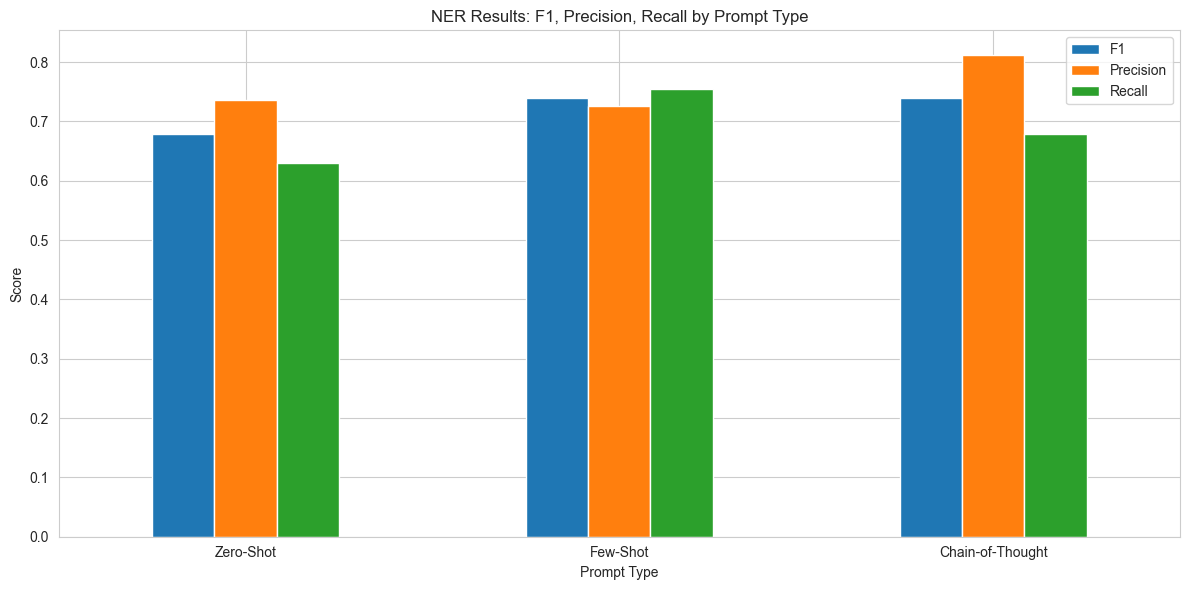


Summary:
     Prompt Type       F1  Precision   Recall  Accuracy
       Zero-Shot 0.678087   0.735294 0.629139  0.877672
        Few-Shot 0.739779   0.725191 0.754967  0.889764
Chain-of-Thought 0.739350   0.812698 0.678146  0.907480


In [11]:
# Cell 11: Save Results (Single CSV and PNG)

import os
from datetime import datetime

print("=" * 70)
print("Saving Results")
print("=" * 70)

os.makedirs("results", exist_ok=True)

# Create summary comparison table
if all(key in globals() for key in ['few_shot_metrics', 'cot_metrics', 'zero_shot_metrics']):
    summary_data = {
        'Prompt Type': ['Zero-Shot', 'Few-Shot', 'Chain-of-Thought'],
        'F1': [
            zero_shot_metrics.get('F1_Overall', 0),
            few_shot_metrics.get('F1_Overall', 0),
            cot_metrics.get('F1_Overall', 0)
        ],
        'Precision': [
            zero_shot_metrics.get('Precision_Overall', 0),
            few_shot_metrics.get('Precision_Overall', 0),
            cot_metrics.get('Precision_Overall', 0)
        ],
        'Recall': [
            zero_shot_metrics.get('Recall_Overall', 0),
            few_shot_metrics.get('Recall_Overall', 0),
            cot_metrics.get('Recall_Overall', 0)
        ],
        'Accuracy': [
            zero_shot_metrics.get('Accuracy', 0),
            few_shot_metrics.get('Accuracy', 0),
            cot_metrics.get('Accuracy', 0)
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    
    # Save CSV
    csv_file = "results/experiment_results.csv"
    summary_df.to_csv(csv_file, index=False)
    print(f"✅ Results saved to: {csv_file}")
    
    # Create and save plot
    plt.figure(figsize=(10, 6))
    summary_df.set_index('Prompt Type')[['F1', 'Precision', 'Recall']].plot(kind='bar', rot=0)
    plt.title('NER Results: F1, Precision, Recall by Prompt Type')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.tight_layout()
    png_file = "results/experiment_results.png"
    plt.savefig(png_file, dpi=150)
    print(f"✅ Plot saved to: {png_file}")
    plt.show()
    
    print("\n" + "=" * 70)
    print("Summary:")
    print("=" * 70)
    print(summary_df.to_string(index=False))
else:
    print("⚠️ Missing results - please run experiments first")

In [ ]:
# Cell 12: Multi-Model Comparison (Optional - Run if you have multiple models)

import json
from datetime import datetime

print("=" * 70)
print("Saving Experiment Results")
print("=" * 70)

# Create results directory if it doesn't exist
import os
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save Few-Shot Results
if 'few_shot_metrics' in globals() and 'few_shot_predictions' in globals():
    few_shot_results = {
        'metadata': {
            'model': MODEL_NAME,
            'prompt_type': 'few_shot',
            'timestamp': timestamp,
            'dataset': 'selected_140_ontonotes5_samples_no_misc.json',
            'num_samples': len(few_shot_predictions) if 'few_shot_predictions' in globals() else 0
        },
        'metrics': few_shot_metrics,
        'predictions': [
            {
                'sentence': sample['text'],
                'tokens': sample['tokens'],
                'true_labels': true_labels,
                'predicted_labels': pred_labels
            }
            for sample, true_labels, pred_labels in zip(data, few_shot_true_labels, few_shot_predictions)
        ] if 'few_shot_true_labels' in globals() and 'few_shot_predictions' in globals() else []
    }
    
    few_shot_file = f"{results_dir}/few_shot_results_{timestamp}.json"
    with open(few_shot_file, 'w', encoding='utf-8') as f:
        json.dump(few_shot_results, f, indent=2, ensure_ascii=False)
    print(f"✅ Few-Shot results saved to: {few_shot_file}")
    
    # Also save as CSV for easy viewing
    few_shot_df = pd.DataFrame([few_shot_metrics])
    few_shot_csv = f"{results_dir}/few_shot_metrics_{timestamp}.csv"
    few_shot_df.to_csv(few_shot_csv, index=False)
    print(f"✅ Few-Shot metrics saved to: {few_shot_csv}")
else:
    print("⚠️ Few-Shot results not found in memory")

# Save Chain-of-Thought Results
if 'cot_metrics' in globals() and 'cot_predictions' in globals():
    cot_results = {
        'metadata': {
            'model': MODEL_NAME,
            'prompt_type': 'chain_of_thought',
            'timestamp': timestamp,
            'dataset': 'selected_140_ontonotes5_samples_no_misc.json',
            'num_samples': len(cot_predictions) if 'cot_predictions' in globals() else 0
        },
        'metrics': cot_metrics,
        'predictions': [
            {
                'sentence': sample['text'],
                'tokens': sample['tokens'],
                'true_labels': true_labels,
                'predicted_labels': pred_labels
            }
            for sample, true_labels, pred_labels in zip(data, cot_true_labels, cot_predictions)
        ] if 'cot_true_labels' in globals() and 'cot_predictions' in globals() else []
    }
    
    cot_file = f"{results_dir}/cot_results_{timestamp}.json"
    with open(cot_file, 'w', encoding='utf-8') as f:
        json.dump(cot_results, f, indent=2, ensure_ascii=False)
    print(f"✅ Chain-of-Thought results saved to: {cot_file}")
    
    # Also save as CSV for easy viewing
    cot_df = pd.DataFrame([cot_metrics])
    cot_csv = f"{results_dir}/cot_metrics_{timestamp}.csv"
    cot_df.to_csv(cot_csv, index=False)
    print(f"✅ Chain-of-Thought metrics saved to: {cot_csv}")
else:
    print("⚠️ Chain-of-Thought results not found in memory")

# Save Zero-Shot Results (if available)
if 'zero_shot_metrics' in globals() and 'zero_shot_predictions' in globals():
    zero_shot_results = {
        'metadata': {
            'model': MODEL_NAME,
            'prompt_type': 'zero_shot',
            'timestamp': timestamp,
            'dataset': 'selected_140_ontonotes5_samples_no_misc.json',
            'num_samples': len(zero_shot_predictions) if 'zero_shot_predictions' in globals() else 0
        },
        'metrics': zero_shot_metrics,
        'predictions': [
            {
                'sentence': sample['text'],
                'tokens': sample['tokens'],
                'true_labels': true_labels,
                'predicted_labels': pred_labels
            }
            for sample, true_labels, pred_labels in zip(data, zero_shot_true_labels, zero_shot_predictions)
        ] if 'zero_shot_true_labels' in globals() and 'zero_shot_predictions' in globals() else []
    }
    
    zero_shot_file = f"{results_dir}/zero_shot_results_{timestamp}.json"
    with open(zero_shot_file, 'w', encoding='utf-8') as f:
        json.dump(zero_shot_results, f, indent=2, ensure_ascii=False)
    print(f"✅ Zero-Shot results saved to: {zero_shot_file}")
    
    zero_shot_df = pd.DataFrame([zero_shot_metrics])
    zero_shot_csv = f"{results_dir}/zero_shot_metrics_{timestamp}.csv"
    zero_shot_df.to_csv(zero_shot_csv, index=False)
    print(f"✅ Zero-Shot metrics saved to: {zero_shot_csv}")
else:
    print("⚠️ Zero-Shot results not found in memory")

# Create summary comparison table
if all(key in globals() for key in ['few_shot_metrics', 'cot_metrics', 'zero_shot_metrics']):
    summary_data = {
        'Prompt Type': ['Zero-Shot', 'Few-Shot', 'Chain-of-Thought'],
        'F1': [
            zero_shot_metrics.get('F1_Overall', 0),
            few_shot_metrics.get('F1_Overall', 0),
            cot_metrics.get('F1_Overall', 0)
        ],
        'Precision': [
            zero_shot_metrics.get('Precision_Overall', 0),
            few_shot_metrics.get('Precision_Overall', 0),
            cot_metrics.get('Precision_Overall', 0)
        ],
        'Recall': [
            zero_shot_metrics.get('Recall_Overall', 0),
            few_shot_metrics.get('Recall_Overall', 0),
            cot_metrics.get('Recall_Overall', 0)
        ],
        'Accuracy': [
            zero_shot_metrics.get('Accuracy', 0),
            few_shot_metrics.get('Accuracy', 0),
            cot_metrics.get('Accuracy', 0)
        ]
    }
    summary_df = pd.DataFrame(summary_data)
    summary_file = f"{results_dir}/summary_comparison_{timestamp}.csv"
    summary_df.to_csv(summary_file, index=False)
    print(f"\n✅ Summary comparison saved to: {summary_file}")
    print("\n" + "=" * 70)
    print("Summary Comparison:")
    print("=" * 70)
    print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("✅ All results saved successfully!")
print("=" * 70)

# Cell 12: Multi-Model Comparison (Optional - Run if you have multiple models)

# Models to test (uncomment the ones you have available)
MODELS_TO_TEST = [
    'llama3.1:8b',
    # 'qwen2.5:32b',  # Uncomment if available
    # 'gemma2:27b',   # Uncomment if available
    # 'mistral:7b-instruct-v0.3',  # Uncomment if available
]

# Store results
comparison_results = []

print("=" * 70)
print("Multi-Model Comparison")
print("=" * 70)

# Save original model name
original_model = MODEL_NAME

for model_name in MODELS_TO_TEST:
    print(f"\n{'='*70}")
    print(f"Testing model: {model_name}")
    print(f"{'='*70}")
    
    # Update model name
    MODEL_NAME = model_name
    
    try:
        # Test connection
        test_response = requests.get(f"{OLLAMA_BASE_URL}/api/tags", timeout=5)
        test_response.raise_for_status()
        models_available = [m['name'] for m in test_response.json().get('models', [])]
        
        if model_name not in models_available:
            print(f"⚠️ Model {model_name} not available. Skipping...")
            continue
        
        # Run zero-shot only (to save time - uncomment to run all prompt types)
        print(f"Running zero-shot for {model_name}...")
        model_zero_predictions = []
        model_zero_true = []
        
        for idx, sample in enumerate(tqdm(data[:20], desc=f"{model_name[:15]} Zero-shot")):  # Test on first 20 for speed
            if idx > 0:
                time.sleep(1.0)
            try:
                pred = predict(sample['text'], 'zero_shot', tokens=sample['tokens'])
                model_zero_predictions.append(pred)
                model_zero_true.append(sample['labels'])
            except Exception as e:
                print(f"  Error at sample {idx+1}: {e}")
                model_zero_predictions.append(['O'] * len(sample['tokens']))
                model_zero_true.append(sample['labels'])
        
        # Calculate metrics
        model_metrics = calculate_token_level_metrics(model_zero_true, model_zero_predictions)
        
        comparison_results.append({
            'Model': model_name,
            'Prompt': 'Zero-Shot',
            'F1': model_metrics['F1_Overall'],
            'Precision': model_metrics['Precision_Overall'],
            'Recall': model_metrics['Recall_Overall'],
            'Accuracy': model_metrics['Accuracy']
        })
        
        print(f"✅ {model_name} Zero-Shot F1: {model_metrics['F1_Overall']:.4f}")
        
    except Exception as e:
        print(f"❌ Error testing {model_name}: {e}")
        continue

# Restore original model
MODEL_NAME = original_model

# Create comparison DataFrame
if comparison_results:
    comparison_df = pd.DataFrame(comparison_results)
    print("\n" + "=" * 70)
    print("Comparison Results:")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    
    # Save to CSV
    comparison_df.to_csv('model_comparison_results.csv', index=False)
    print("\n✅ Results saved to 'model_comparison_results.csv'")
    
    # Create visualization
    if len(comparison_results) > 1:
        plt.figure(figsize=(10, 6))
        comparison_df_plot = comparison_df.set_index('Model')
        comparison_df_plot[['F1', 'Precision', 'Recall']].plot(kind='bar', rot=45)
        plt.title('Model Comparison: F1, Precision, Recall')
        plt.ylabel('Score')
        plt.legend(loc='best')
        plt.tight_layout()
        plt.savefig('model_comparison_plot.png', dpi=150)
        print("✅ Plot saved to 'model_comparison_plot.png'")
        plt.show()
else:
    print("⚠️ No results to compare")

Saving Experiment Results
✅ Few-Shot results saved to: results/few_shot_results_20251221_200059.json
✅ Few-Shot metrics saved to: results/few_shot_metrics_20251221_200059.csv
✅ Chain-of-Thought results saved to: results/cot_results_20251221_200059.json
✅ Chain-of-Thought metrics saved to: results/cot_metrics_20251221_200059.csv
✅ Zero-Shot results saved to: results/zero_shot_results_20251221_200059.json
✅ Zero-Shot metrics saved to: results/zero_shot_metrics_20251221_200059.csv

✅ Summary comparison saved to: results/summary_comparison_20251221_200059.csv

Summary Comparison:
     Prompt Type       F1  Precision   Recall  Accuracy
       Zero-Shot 0.678087   0.735294 0.629139  0.877672
        Few-Shot 0.739779   0.725191 0.754967  0.889764
Chain-of-Thought 0.739350   0.812698 0.678146  0.907480

✅ All results saved successfully!
Multi-Model Comparison

Testing model: llama3.1:8b
Running zero-shot for llama3.1:8b...


llama3.1:8b Zero-shot:   0%|          | 0/20 [00:00<?, ?it/s]

llama3.1:8b Zero-shot: 100%|██████████| 20/20 [00:49<00:00,  2.47s/it]

✅ llama3.1:8b Zero-Shot F1: 0.7383

Comparison Results:
      Model    Prompt       F1  Precision   Recall  Accuracy
llama3.1:8b Zero-Shot 0.738255   0.723684 0.753425  0.863281

✅ Results saved to 'model_comparison_results.csv'


In [13]:
# Cell 12: Entity-Level Evaluation using spaCy Scorer

from typing import List, Dict

try:
    import spacy
    from spacy.scorer import Scorer
    from spacy.training.example import Example
    
    # Load spaCy model (blank model is sufficient for evaluation)
    try:
        nlp = spacy.load("en_core_web_sm")
    except OSError:
        print("⚠️ spaCy model not found, using blank('en')")
        nlp = spacy.blank("en")
    
    SPACY_AVAILABLE = True
except ImportError:
    print("⚠️ spaCy not available. Please install: pip install spacy && python -m spacy download en_core_web_sm")
    SPACY_AVAILABLE = False

def labels_to_spacy_doc(text: str, tokens: List[str], labels: List[str], nlp) -> spacy.tokens.Doc:
    """Convert token labels to spacy Doc with entities"""
    # Create Doc from text
    doc = nlp(text)
    
    # Find character spans for entities from labels
    entities = []
    current_entity = None
    current_start = None
    current_end = None
    
    # Map tokens to character positions in text
    char_positions = []
    pos = 0
    text_lower = text.lower()
    
    for token in tokens:
        token_lower = token.lower()
        token_start = text_lower.find(token_lower, pos)
        if token_start != -1:
            char_positions.append((token_start, token_start + len(token)))
            pos = token_start + len(token)
        else:
            # Approximate position
            char_positions.append((pos, pos + len(token)))
            pos += len(token) + 1
    
    # Extract entity spans
    for i, (label, (start, end)) in enumerate(zip(labels, char_positions)):
        if label != 'O':
            if current_entity is None or current_entity != label:
                # End previous entity if any
                if current_entity is not None:
                    entities.append((current_start, current_end, current_entity))
                # Start new entity
                current_entity = label
                current_start = start
                current_end = end
            else:
                # Extend current entity
                current_end = end
        else:
            # End current entity if any
            if current_entity is not None:
                entities.append((current_start, current_end, current_entity))
                current_entity = None
    
    # Add last entity if exists
    if current_entity is not None:
        entities.append((current_start, current_end, current_entity))
    
    # Set entities on doc
    doc.set_ents([doc.char_span(start, end, label=ent_type) 
                  for start, end, ent_type in entities 
                  if doc.char_span(start, end, label=ent_type) is not None])
    
    return doc


def calculate_spacy_entity_metrics(true_docs: List[spacy.tokens.Doc], 
                                   pred_docs: List[spacy.tokens.Doc]) -> Dict:
    """Calculate entity-level metrics using spaCy Scorer"""
    if not SPACY_AVAILABLE:
        return {}
    
    scorer = Scorer(nlp)
    
    # Create Example objects for scorer
    examples = []
    for true_doc, pred_doc in zip(true_docs, pred_docs):
        example = Example(predicted=pred_doc, reference=true_doc)
        examples.append(example)
    
    # Calculate scores
    scores = scorer.score(examples)
    
    # Extract entity-level metrics
    ents_p = scores.get('ents_p', 0.0)
    ents_r = scores.get('ents_r', 0.0)
    ents_f = scores.get('ents_f', 0.0)
    ents_per_type = scores.get('ents_per_type', {})
    
    metrics = {
        'F1': ents_f,
        'Precision': ents_p,
        'Recall': ents_r,
        'per_type': ents_per_type
    }
    
    return metrics


# Check if results exist and calculate entity-level metrics
print("=" * 70)
print("Entity-Level Evaluation using spaCy Scorer")
print("=" * 70)

if not SPACY_AVAILABLE:
    print("⚠️ spaCy not available. Skipping entity-level evaluation.")
else:
    results_found = False
    
    # Zero-Shot
    if 'zero_shot_predictions' in globals() and 'zero_shot_true_labels' in globals() and 'zero_shot_tokens_list' in globals() and 'data' in globals():
        print("\n📊 Calculating Zero-Shot entity-level metrics...")
        zero_spacy_true = [labels_to_spacy_doc(sample['text'], tokens, true_labels, nlp) 
                          for sample, tokens, true_labels in zip(data, zero_shot_tokens_list, zero_shot_true_labels)]
        zero_spacy_pred = [labels_to_spacy_doc(sample['text'], tokens, pred_labels, nlp) 
                          for sample, tokens, pred_labels in zip(data, zero_shot_tokens_list, zero_shot_predictions)]
        zero_spacy_metrics = calculate_spacy_entity_metrics(zero_spacy_true, zero_spacy_pred)
        results_found = True
    else:
        zero_spacy_metrics = {}
        print("⚠️ Zero-Shot results not found in memory")
    
    # Few-Shot
    if 'few_shot_predictions' in globals() and 'few_shot_true_labels' in globals() and 'few_shot_tokens_list' in globals() and 'data' in globals():
        print("📊 Calculating Few-Shot entity-level metrics...")
        few_spacy_true = [labels_to_spacy_doc(sample['text'], tokens, true_labels, nlp) 
                         for sample, tokens, true_labels in zip(data, few_shot_tokens_list, few_shot_true_labels)]
        few_spacy_pred = [labels_to_spacy_doc(sample['text'], tokens, pred_labels, nlp) 
                         for sample, tokens, pred_labels in zip(data, few_shot_tokens_list, few_shot_predictions)]
        few_spacy_metrics = calculate_spacy_entity_metrics(few_spacy_true, few_spacy_pred)
        results_found = True
    else:
        few_spacy_metrics = {}
        print("⚠️ Few-Shot results not found in memory")
    
    # Chain-of-Thought
    if 'cot_predictions' in globals() and 'cot_true_labels' in globals() and 'cot_tokens_list' in globals() and 'data' in globals():
        print("📊 Calculating Chain-of-Thought entity-level metrics...")
        cot_spacy_true = [labels_to_spacy_doc(sample['text'], tokens, true_labels, nlp) 
                         for sample, tokens, true_labels in zip(data, cot_tokens_list, cot_true_labels)]
        cot_spacy_pred = [labels_to_spacy_doc(sample['text'], tokens, pred_labels, nlp) 
                         for sample, tokens, pred_labels in zip(data, cot_tokens_list, cot_predictions)]
        cot_spacy_metrics = calculate_spacy_entity_metrics(cot_spacy_true, cot_spacy_pred)
        results_found = True
    else:
        cot_spacy_metrics = {}
        print("⚠️ Chain-of-Thought results not found in memory")
    
    # Display results
    if results_found:
        print("\n" + "=" * 70)
        print("Entity-Level Results (spaCy Scorer):")
        print("=" * 70)
        print(f"{'Prompt Type':<20s} {'F1':<8s} {'Precision':<10s} {'Recall':<10s}")
        print("-" * 70)
        
        if zero_spacy_metrics:
            print(f"{'Zero-Shot':<20s} {zero_spacy_metrics.get('F1', 0):<8.4f} {zero_spacy_metrics.get('Precision', 0):<10.4f} {zero_spacy_metrics.get('Recall', 0):<10.4f}")
        
        if few_spacy_metrics:
            print(f"{'Few-Shot':<20s} {few_spacy_metrics.get('F1', 0):<8.4f} {few_spacy_metrics.get('Precision', 0):<10.4f} {few_spacy_metrics.get('Recall', 0):<10.4f}")
        
        if cot_spacy_metrics:
            print(f"{'Chain-of-Thought':<20s} {cot_spacy_metrics.get('F1', 0):<8.4f} {cot_spacy_metrics.get('Precision', 0):<10.4f} {cot_spacy_metrics.get('Recall', 0):<10.4f}")
        
        print("=" * 70)
        
        # Per-entity-type metrics
        if zero_spacy_metrics.get('per_type') or few_spacy_metrics.get('per_type') or cot_spacy_metrics.get('per_type'):
            print("\nPer-Entity-Type Metrics:")
            print("=" * 70)
            all_types = set()
            if zero_spacy_metrics.get('per_type'):
                all_types.update(zero_spacy_metrics['per_type'].keys())
            if few_spacy_metrics.get('per_type'):
                all_types.update(few_spacy_metrics['per_type'].keys())
            if cot_spacy_metrics.get('per_type'):
                all_types.update(cot_spacy_metrics['per_type'].keys())
            
            for ent_type in sorted(all_types):
                print(f"\n{ent_type}:")
                if zero_spacy_metrics.get('per_type', {}).get(ent_type):
                    z = zero_spacy_metrics['per_type'][ent_type]
                    print(f"  Zero-Shot:     F1={z.get('f', 0):.4f} P={z.get('p', 0):.4f} R={z.get('r', 0):.4f}")
                if few_spacy_metrics.get('per_type', {}).get(ent_type):
                    f = few_spacy_metrics['per_type'][ent_type]
                    print(f"  Few-Shot:      F1={f.get('f', 0):.4f} P={f.get('p', 0):.4f} R={f.get('r', 0):.4f}")
                if cot_spacy_metrics.get('per_type', {}).get(ent_type):
                    c = cot_spacy_metrics['per_type'][ent_type]
                    print(f"  Chain-of-Thought: F1={c.get('f', 0):.4f} P={c.get('p', 0):.4f} R={c.get('r', 0):.4f}")
        
        print("\n✅ Entity-level evaluation complete!")
    else:
        print("\n⚠️ No results found in memory. Please run experiments first.")


Entity-Level Evaluation using spaCy Scorer

📊 Calculating Zero-Shot entity-level metrics...
📊 Calculating Few-Shot entity-level metrics...
📊 Calculating Chain-of-Thought entity-level metrics...

Entity-Level Results (spaCy Scorer):
Prompt Type          F1       Precision  Recall    
----------------------------------------------------------------------
Zero-Shot            0.5919   0.6119     0.5732    
Few-Shot             0.6499   0.6459     0.6540    
Chain-of-Thought     0.6005   0.6400     0.5657    

Per-Entity-Type Metrics:

CURRENCY:
  Zero-Shot:     F1=0.2466 P=0.3214 R=0.2000
  Few-Shot:      F1=0.4468 P=0.4286 R=0.4667
  Chain-of-Thought: F1=0.4658 P=0.6071 R=0.3778

LOCATION:
  Zero-Shot:     F1=0.8214 P=0.8313 R=0.8118
  Few-Shot:      F1=0.7630 P=0.7500 R=0.7765
  Chain-of-Thought: F1=0.7746 P=0.7614 R=0.7882

ORGANIZATION:
  Zero-Shot:     F1=0.6667 P=0.6354 R=0.7011
  Few-Shot:      F1=0.7447 P=0.6931 R=0.8046
  Chain-of-Thought: F1=0.6220 P=0.6623 R=0.5862

PERSON:
  Z